# K-Means Clustering: Success & Failure Cases
# K-Means Clustering: Kasus Sukses & Gagal

Notebook ini mendemonstrasikan kapan K-Means berhasil dan kapan gagal menggunakan 6 dataset yang menantang.

This notebook demonstrates when K-Means succeeds and fails using 6 challenging datasets.

## Import Libraries / Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## Helper Function for Visualization / Fungsi Helper untuk Visualisasi

In [2]:
def plot_clustering(X, y_true, y_pred, title, centers=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # True labels
    if len(np.unique(y_true)) > 1:
        ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.6)
    else:
        ax1.scatter(X[:, 0], X[:, 1], c='gray', s=30, alpha=0.6)
    ax1.set_title('True Labels / Label Asli')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    
    # K-Means predictions
    ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30, alpha=0.6)
    if centers is not None:
        ax2.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
        ax2.legend()
    ax2.set_title('K-Means Predictions / Prediksi K-Means')
    ax2.set_xlabel('Feature 1')
    ax2.set_ylabel('Feature 2')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Dataset 1: Noisy Circles (Concentric) / Lingkaran Bising (Konsentris)

**Problem / Masalah:** Non-spherical clusters / Cluster non-spherical

**K-Means Assumption Violated / Asumsi Dilanggar:** Spherical clusters / Cluster bulat

**Expected / Ekspektasi:** K-Means akan GAGAL / K-Means will FAIL

Silhouette Score: 0.353
Inertia: 634.33


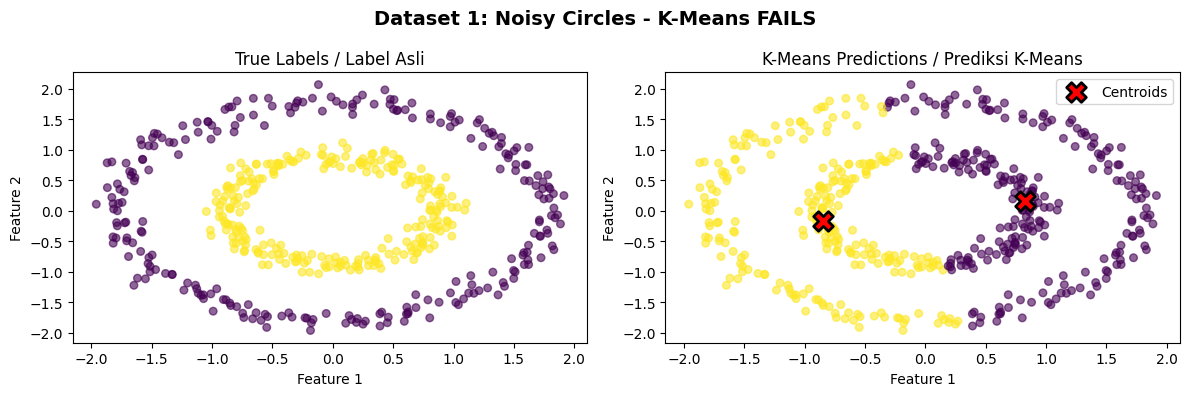

In [3]:
X_circles, y_circles = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
X_circles = StandardScaler().fit_transform(X_circles)

kmeans_circles = KMeans(n_clusters=2, random_state=42, n_init=10)
y_pred_circles = kmeans_circles.fit_predict(X_circles)

sil_circles = silhouette_score(X_circles, y_pred_circles)
inertia_circles = kmeans_circles.inertia_

print(f"Silhouette Score: {sil_circles:.3f}")
print(f"Inertia: {inertia_circles:.2f}")

plot_clustering(X_circles, y_circles, y_pred_circles, 'Dataset 1: Noisy Circles - K-Means FAILS', kmeans_circles.cluster_centers_)

### Analysis / Analisis

**Mengapa Gagal / Why Fails:**
- Lingkaran konsentris (non-spherical) / Concentric circles (non-spherical)
- K-Means membuat batas lurus / K-Means creates straight boundary
- Silhouette Score rendah / Low Silhouette Score

**Alternatif:** DBSCAN atau Spectral Clustering

---
## Dataset 2: Noisy Moons / Bulan Bising

**Problem / Masalah:** Non-convex clusters / Cluster non-convex

**Expected / Ekspektasi:** K-Means akan GAGAL / K-Means will FAIL

Silhouette Score: 0.496
Inertia: 416.01


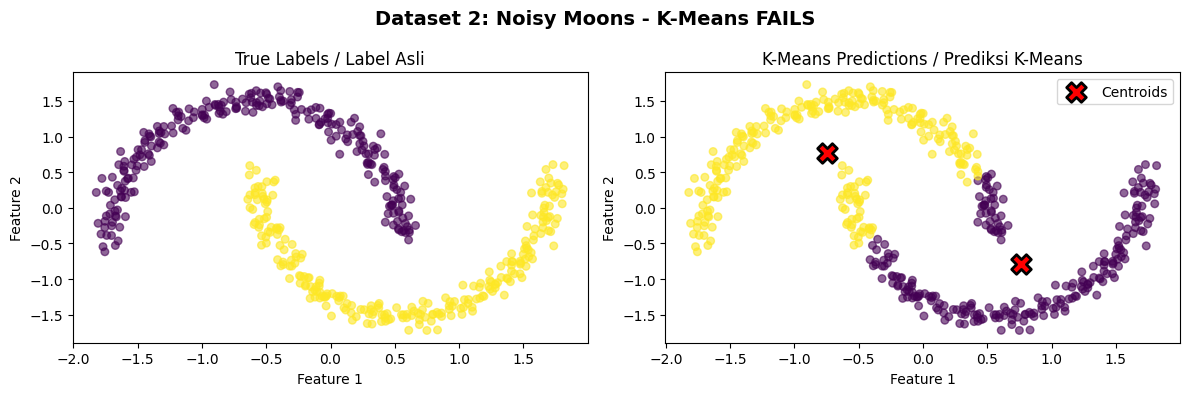

In [4]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
y_pred_moons = kmeans_moons.fit_predict(X_moons)

sil_moons = silhouette_score(X_moons, y_pred_moons)
inertia_moons = kmeans_moons.inertia_

print(f"Silhouette Score: {sil_moons:.3f}")
print(f"Inertia: {inertia_moons:.2f}")

plot_clustering(X_moons, y_moons, y_pred_moons, 'Dataset 2: Noisy Moons - K-Means FAILS', kmeans_moons.cluster_centers_)

### Analysis / Analisis

**Mengapa Gagal / Why Fails:**
- Bentuk bulan sabit (non-convex) / Crescent shape (non-convex)
- K-Means membuat batas lurus / K-Means creates straight boundary

**Alternatif:** DBSCAN atau Agglomerative Clustering

---
## Dataset 3: Overlapping Clusters / Cluster Tumpang Tindih

**Problem / Masalah:** Clusters overlap significantly / Cluster saling tumpang tindih

**K-Means Assumption Violated / Asumsi Dilanggar:** Well-separated clusters / Cluster terpisah jelas

**Expected / Ekspektasi:** K-Means akan KESULITAN / K-Means will STRUGGLE

Silhouette Score: 0.473
Inertia: 294.43


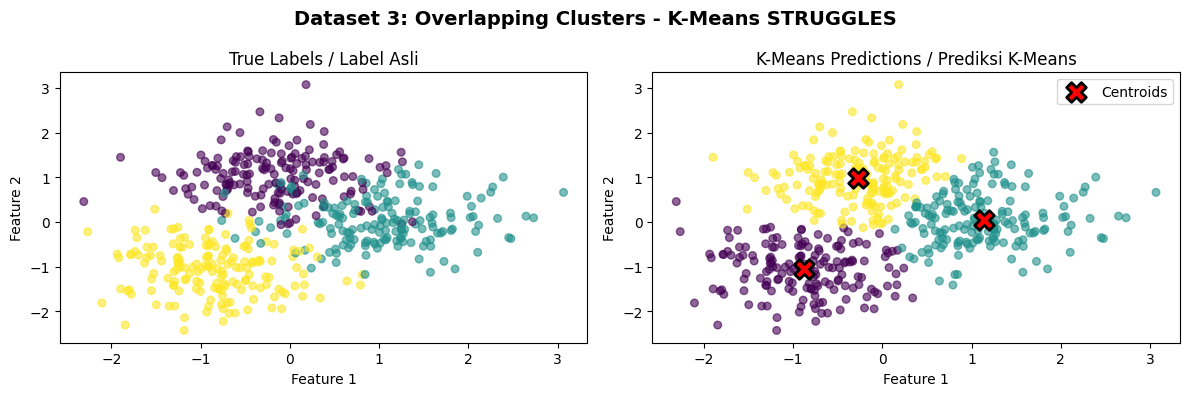

In [5]:
# Generate overlapping blobs
X_overlap, y_overlap = make_blobs(n_samples=500, centers=3, cluster_std=2.0, center_box=(-5, 5), random_state=42)
X_overlap = StandardScaler().fit_transform(X_overlap)

kmeans_overlap = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_overlap = kmeans_overlap.fit_predict(X_overlap)

sil_overlap = silhouette_score(X_overlap, y_pred_overlap)
inertia_overlap = kmeans_overlap.inertia_

print(f"Silhouette Score: {sil_overlap:.3f}")
print(f"Inertia: {inertia_overlap:.2f}")

plot_clustering(X_overlap, y_overlap, y_pred_overlap, 'Dataset 3: Overlapping Clusters - K-Means STRUGGLES', kmeans_overlap.cluster_centers_)

### Analysis / Analisis

**Mengapa Kesulitan / Why Struggles:**
- Cluster saling tumpang tindih / Clusters overlap significantly
- Batas tidak jelas / Boundaries are unclear
- K-Means membuat batas paksa / K-Means forces hard boundaries
- Silhouette Score rendah-sedang / Low-moderate Silhouette Score

**Alternatif:** Gaussian Mixture Models (GMM) dengan soft clustering / with soft clustering

---
## Dataset 4: Anisotropic / Anisotropik

**Problem / Masalah:** Elongated clusters / Cluster memanjang

**Expected / Ekspektasi:** K-Means akan KESULITAN / K-Means will STRUGGLE

Silhouette Score: 0.503
Inertia: 167.80


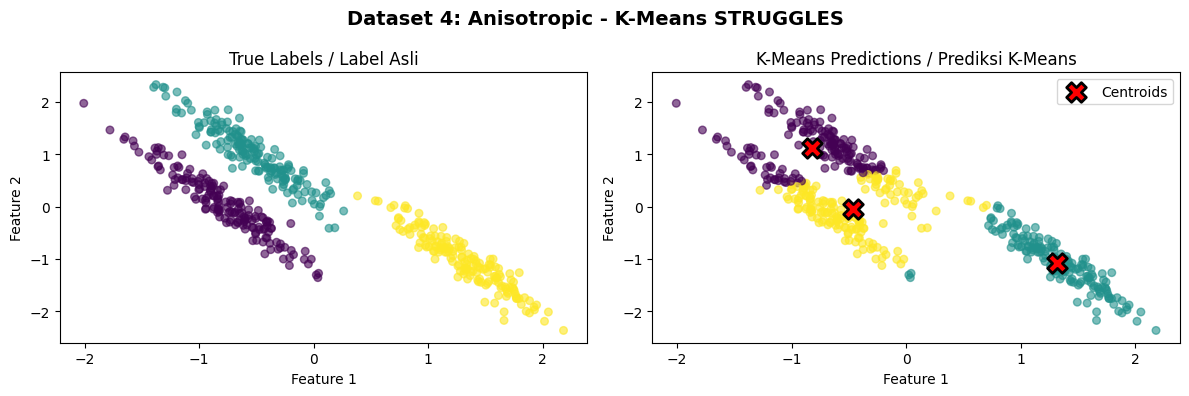

In [6]:
X_aniso, y_aniso = make_blobs(n_samples=500, centers=3, random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X_aniso, transformation)
X_aniso = StandardScaler().fit_transform(X_aniso)

kmeans_aniso = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_aniso = kmeans_aniso.fit_predict(X_aniso)

sil_aniso = silhouette_score(X_aniso, y_pred_aniso)
inertia_aniso = kmeans_aniso.inertia_

print(f"Silhouette Score: {sil_aniso:.3f}")
print(f"Inertia: {inertia_aniso:.2f}")

plot_clustering(X_aniso, y_aniso, y_pred_aniso, 'Dataset 4: Anisotropic - K-Means STRUGGLES', kmeans_aniso.cluster_centers_)

### Analysis / Analisis

**Mengapa Kesulitan / Why Struggles:**
- Cluster teregang / Stretched clusters
- K-Means membuat batas melingkar / K-Means creates circular boundaries

**Alternatif:** GMM atau Agglomerative Clustering

---
## Dataset 5: Regular Blobs / Blob Reguler (IDEAL)

**Characteristics / Karakteristik:** Spherical, equal variance, well-separated

**Expected / Ekspektasi:** K-Means akan BERHASIL / K-Means will SUCCEED

Silhouette Score: 0.844
Inertia: 31.61


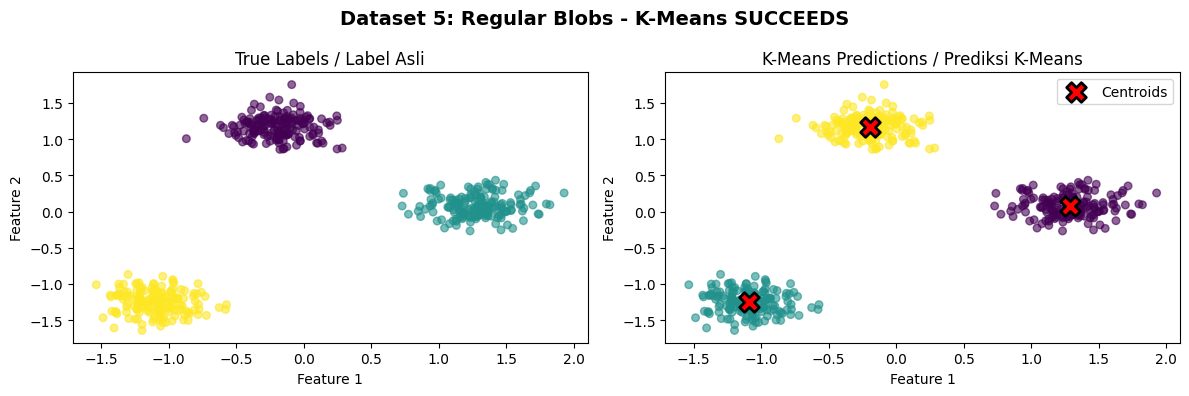

In [7]:
X_blobs, y_blobs = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)
X_blobs = StandardScaler().fit_transform(X_blobs)

kmeans_blobs = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_blobs = kmeans_blobs.fit_predict(X_blobs)

sil_blobs = silhouette_score(X_blobs, y_pred_blobs)
inertia_blobs = kmeans_blobs.inertia_

print(f"Silhouette Score: {sil_blobs:.3f}")
print(f"Inertia: {inertia_blobs:.2f}")

plot_clustering(X_blobs, y_blobs, y_pred_blobs, 'Dataset 5: Regular Blobs - K-Means SUCCEEDS', kmeans_blobs.cluster_centers_)

### Analysis / Analisis

**Mengapa Berhasil / Why Succeeds:**
- Cluster bulat / Spherical clusters
- Variansi sama / Equal variance
- Terpisah jelas / Well-separated
- Silhouette Score tinggi / High Silhouette Score

**Ini kasus IDEAL untuk K-Means! / This is the IDEAL case for K-Means!**

---
## Dataset 6: No Structure / Tanpa Struktur

**Problem / Masalah:** No natural clusters / Tidak ada cluster natural

**Expected / Ekspektasi:** K-Means akan OVERFIT / K-Means will OVERFIT

Silhouette Score: 0.407
Inertia: 360.49


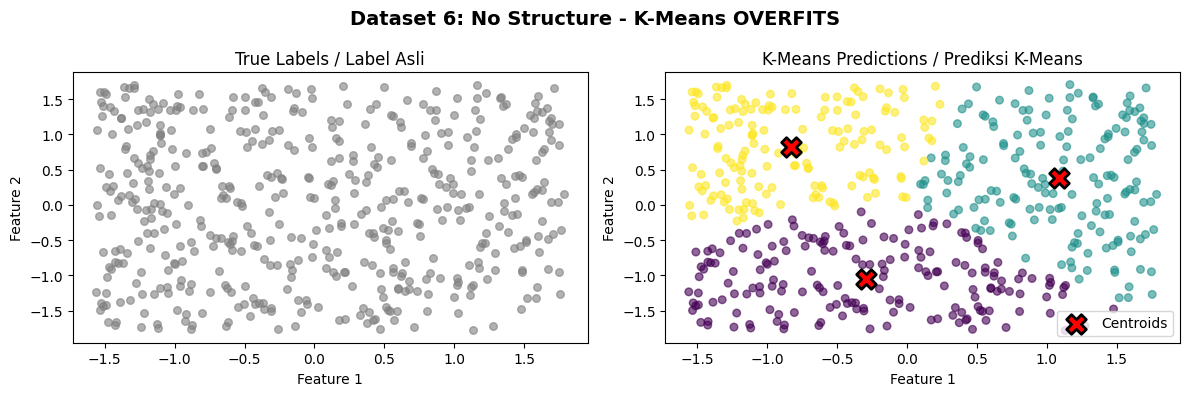

In [8]:
np.random.seed(42)
X_random = np.random.rand(500, 2)
y_random = np.zeros(500)
X_random = StandardScaler().fit_transform(X_random)

kmeans_random = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_random = kmeans_random.fit_predict(X_random)

sil_random = silhouette_score(X_random, y_pred_random)
inertia_random = kmeans_random.inertia_

print(f"Silhouette Score: {sil_random:.3f}")
print(f"Inertia: {inertia_random:.2f}")

plot_clustering(X_random, y_random, y_pred_random, 'Dataset 6: No Structure - K-Means OVERFITS', kmeans_random.cluster_centers_)

### Analysis / Analisis

**Mengapa Overfit / Why Overfits:**
- Tidak ada cluster natural / No natural clusters
- K-Means memaksa k cluster / K-Means forces k clusters
- Batas artifisial / Artificial boundaries

**Pelajaran / Lesson:** Validasi dulu apakah cluster ada! / Validate if clusters exist first!

---
# Comparison Grid / Grid Perbandingan

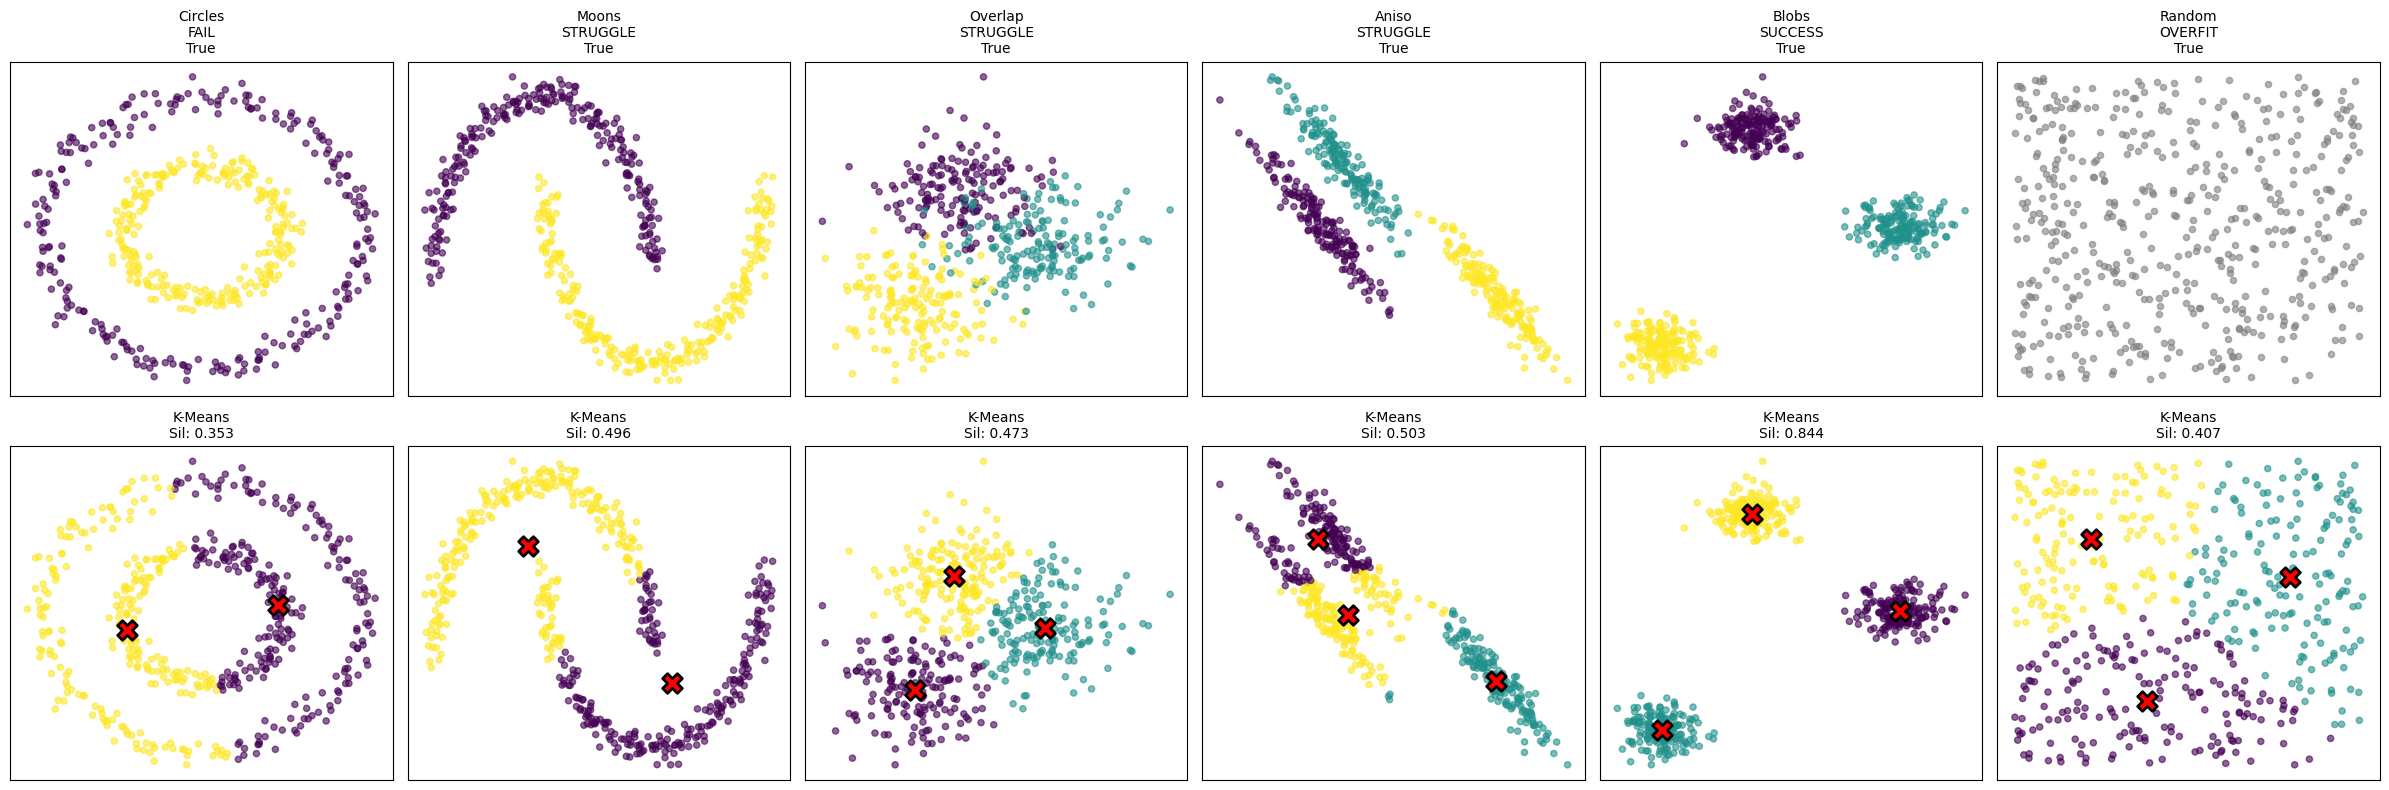

In [9]:
datasets = [
    (X_circles, y_circles, y_pred_circles, 'Circles\nFAIL', kmeans_circles.cluster_centers_, sil_circles),
    (X_moons, y_moons, y_pred_moons, 'Moons\nSTRUGGLE', kmeans_moons.cluster_centers_, sil_moons),
    (X_overlap, y_overlap, y_pred_overlap, 'Overlap\nSTRUGGLE', kmeans_overlap.cluster_centers_, sil_overlap),
    (X_aniso, y_aniso, y_pred_aniso, 'Aniso\nSTRUGGLE', kmeans_aniso.cluster_centers_, sil_aniso),
    (X_blobs, y_blobs, y_pred_blobs, 'Blobs\nSUCCESS', kmeans_blobs.cluster_centers_, sil_blobs),
    (X_random, y_random, y_pred_random, 'Random\nOVERFIT', kmeans_random.cluster_centers_, sil_random)
]

fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for idx, (X, y_true, y_pred, title, centers, sil) in enumerate(datasets):
    ax1 = axes[0, idx]
    if len(np.unique(y_true)) > 1:
        ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=20, alpha=0.6)
    else:
        ax1.scatter(X[:, 0], X[:, 1], c='gray', s=20, alpha=0.6)
    ax1.set_title(f'{title}\nTrue', fontsize=10)
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    ax2 = axes[1, idx]
    ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=20, alpha=0.6)
    ax2.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2)
    ax2.set_title(f'K-Means\nSil: {sil:.3f}', fontsize=10)
    ax2.set_xticks([])
    ax2.set_yticks([])

plt.tight_layout()
plt.show()

---
# Summary / Ringkasan

In [10]:
import pandas as pd

summary = pd.DataFrame({
    'Dataset': ['Circles', 'Moons', 'Overlap', 'Aniso', 'Blobs', 'Random'],
    'Problem': ['Non-spherical', 'Non-convex', 'Overlapping', 'Elongated', 'Ideal', 'No clusters'],
    'Silhouette': [sil_circles, sil_moons, sil_overlap, sil_aniso, sil_blobs, sil_random],
    'Result': ['FAIL', 'STRUGGLE', 'STRUGGLE', 'STRUGGLE', 'SUCCESS', 'OVERFIT']
})

print(summary.to_string(index=False))

Dataset       Problem  Silhouette   Result
Circles Non-spherical    0.353136     FAIL
  Moons    Non-convex    0.496150 STRUGGLE
Overlap   Overlapping    0.473473 STRUGGLE
  Aniso     Elongated    0.502867 STRUGGLE
  Blobs         Ideal    0.843896  SUCCESS
 Random   No clusters    0.407182  OVERFIT


---
# Kesimpulan / Conclusion

## K-Means Berhasil / Succeeds:
1. Cluster bulat / Spherical clusters
2. Variansi sama / Equal variance
3. Terpisah jelas / Well-separated
4. Jumlah k diketahui / Known k

## K-Means Gagal / Fails:
1. Non-spherical (circles, moons)
2. Variansi berbeda / Different variances
3. Elongated / Memanjang
4. Tidak ada cluster / No clusters

## Best Practices:
1. Visualisasi data dulu / Visualize first
2. Gunakan Elbow Method / Use Elbow Method
3. Hitung Silhouette Score / Calculate Silhouette Score
4. Standardize data
5. Gunakan K-Means++ / Use K-Means++
6. Pertimbangkan alternatif / Consider alternatives:
   - Non-spherical → DBSCAN
   - Different variances → GMM
   - Elongated → Agglomerative
   - Unknown k → DBSCAN/Hierarchical

**K-Means bukan solusi universal! / K-Means is not universal!**